In [1]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import sys
import os

sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.decomposition import PCA
from tqdm.notebook import tqdm
import torch
from dotenv import load_dotenv

load_dotenv()

import transformers
if not hasattr(transformers, "TRANSFORMERS_CACHE"):
    from huggingface_hub.constants import HF_HUB_CACHE
    transformers.TRANSFORMERS_CACHE = HF_HUB_CACHE

from transformer_lens import HookedTransformer

## Config

Replicating Park et al. (2501.00070) but with **generic token labels** (A, B, C, …) to strip out semantic priors.

In [3]:
GRAPH_TYPE = "grid_3x3"   # "grid_3x3" | "ring_4"
SEQ_LENGTHS = [50, 100, 200, 500, 1000]
N_W = 50                  # trailing window size for node-mean computation
SEED = 42                 # random walk seed
DELIMITER = " "           # space-delimited; try "," or "\n" as ablation
MODEL_NAME = "llama-3.1-1b"  # switch to "llama-3.2-1b" for quick tests
LAYERS_TO_PLOT = [0, 8, 16, 24, 31]  # embedding + evenly-spaced + last

## Graph construction

Graph: grid_3x3, nodes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I'], edges: [('A', 'D'), ('A', 'B'), ('B', 'E'), ('B', 'C'), ('C', 'F'), ('D', 'G'), ('D', 'E'), ('E', 'H'), ('E', 'F'), ('F', 'I'), ('G', 'H'), ('H', 'I')]


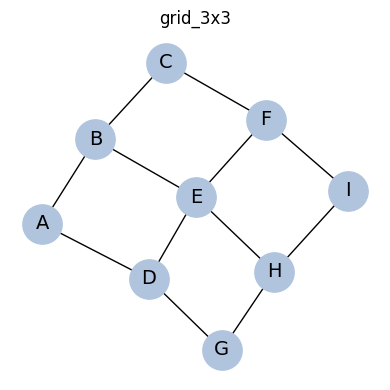

In [18]:
def make_graph(
    graph_type: str,
    node_labels: list[str] | None = None,
) -> tuple[nx.Graph, list[str]]:
    """
    Build a named graph with node labels.
    If node_labels is provided it overrides the default single-letter labels.
    Returns (graph, ordered_node_list).
    """
    if graph_type == "grid_3x3":
        G_raw = nx.grid_2d_graph(3, 3)
        raw_nodes = sorted(G_raw.nodes())
        if node_labels is not None:
            assert len(node_labels) == len(raw_nodes), (
                f"Expected {len(raw_nodes)} labels for grid_3x3, got {len(node_labels)}"
            )
            label_map = {n: node_labels[i] for i, n in enumerate(raw_nodes)}
        else:
            label_map = {n: chr(65 + i) for i, n in enumerate(raw_nodes)}
        G = nx.relabel_nodes(G_raw, label_map)
        nodes = [label_map[n] for n in raw_nodes]
    elif graph_type == "ring_4":
        G_raw = nx.cycle_graph(4)
        if node_labels is not None:
            assert len(node_labels) == 4, (
                f"Expected 4 labels for ring_4, got {len(node_labels)}"
            )
            label_map = {i: node_labels[i] for i in range(4)}
        else:
            label_map = {i: chr(65 + i) for i in range(4)}
        G = nx.relabel_nodes(G_raw, label_map)
        nodes = list(label_map.values())
    else:
        raise ValueError(f"Unknown graph type: {graph_type}")
    return G, nodes


G, NODES = make_graph(GRAPH_TYPE)
print(f"Graph: {GRAPH_TYPE}, nodes: {NODES}, edges: {list(G.edges())}")

fig, ax = plt.subplots(figsize=(4, 4))
nx.draw(G, labels={n: n for n in G.nodes()}, with_labels=True,
        node_color="lightsteelblue", node_size=800, font_size=14, ax=ax)
ax.set_title(GRAPH_TYPE)
plt.tight_layout()
plt.show()

## Random walk & prompt helpers

In [5]:
def random_walk(G: nx.Graph, length: int, seed: int | None = None) -> list[str]:
    rng = np.random.default_rng(seed)
    node_list = list(G.nodes())
    current = node_list[rng.integers(len(node_list))]
    walk = [current]
    for _ in range(length - 1):
        neighbors = list(G.neighbors(walk[-1]))
        current = neighbors[rng.integers(len(neighbors))]
        walk.append(current)
    return walk


def walk_to_prompt(walk: list[str], delimiter: str = " ") -> str:
    return delimiter.join(walk)


# Sanity check
example_walk = random_walk(G, length=20, seed=None)
print("Example walk:", example_walk)
print("Prompt:", walk_to_prompt(example_walk))

Example walk: ['A', 'D', 'A', 'D', 'E', 'D', 'E', 'D', 'E', 'D', 'E', 'H', 'E', 'F', 'I', 'F', 'C', 'F', 'I', 'F']
Prompt: A D A D E D E D E D E H E F I F C F I F


## Device & model loading

In [6]:
if torch.cuda.is_available():
    DEVICE = "cuda"
elif torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"

print(f"Using device: {DEVICE}")

MODEL_IDS = {
    "llama-3.1-8b": "meta-llama/Llama-3.1-8B",
    "llama-3.2-1b": "meta-llama/Llama-3.2-1B",
    "llama-3.1-1b": "meta-llama/Llama-3.2-1B",
    "gemma2-9b": "google/gemma-2-9b",
}


Using device: mps


In [ ]:

model_id = MODEL_IDS[MODEL_NAME]
dtype = torch.float16 if DEVICE == "cuda" else torch.float32

model = HookedTransformer.from_pretrained(
    model_id,
    dtype=dtype,
    device=DEVICE,
    fold_ln=False,
    center_writing_weights=False,
    center_unembed=False,
)
model.eval()

N_LAYERS = model.cfg.n_layers
HIDDEN_DIM = model.cfg.d_model
print(f"Loaded {MODEL_NAME}: {N_LAYERS} layers, hidden_dim={HIDDEN_DIM}")

## Tokenisation check

Verify that each graph node label tokenises to a **single token** (critical for clean activation readout at the last position).

In [10]:
print("Node token check (should each be 1 token):")
for node in NODES:
    toks = model.to_str_tokens(f" {node}", prepend_bos=False)
    print(f"  node='{node}'  →  tokens={toks}  (n={len(toks)})")

Node token check (should each be 1 token):
  node='A'  →  tokens=[' A']  (n=1)
  node='B'  →  tokens=[' B']  (n=1)
  node='C'  →  tokens=[' C']  (n=1)
  node='D'  →  tokens=[' D']  (n=1)
  node='E'  →  tokens=[' E']  (n=1)
  node='F'  →  tokens=[' F']  (n=1)
  node='G'  →  tokens=[' G']  (n=1)
  node='H'  →  tokens=[' H']  (n=1)
  node='I'  →  tokens=[' I']  (n=1)


## Activation extraction (Park et al. §3.1)

One random walk of length `MAX_SEQ_LEN = max(SEQ_LENGTHS)`, one forward pass.

For each context length T (a column in the PCA grid):

1. **Trailing window** `[max(0, T − N_w), T)` of the walk.
2. For each graph node τ, collect the residual-stream activations at every position in the window where τ appears and **average** them → `h_τ^ℓ`.
3. Stack into `H^ℓ(T) ∈ R^{n × d}` — one row per graph node.

**PCA** of `H^ℓ(T)` gives `n` points (one per node). The different T panels are snapshots along the same sequence.

In [7]:
def extract_node_means(
    model: HookedTransformer,
    G: nx.Graph,
    nodes: list[str],
    seq_lengths: list[int],
    seed: int = 42,
    delimiter: str = " ",
    n_w: int = 50,
) -> tuple[dict[int, dict[int, np.ndarray]], list[str]]:
    n_layers = model.cfg.n_layers
    hidden_dim = model.cfg.d_model
    max_seq_len = max(seq_lengths)

    # Guard 1: every node must be a single token as it appears mid-sequence
    # (with leading delimiter), since the indexing assumes 1 token per walk step.
    for node in nodes:
        toks = model.to_str_tokens(f"{delimiter}{node}", prepend_bos=False)
        assert len(toks) == 1, (
            f"Node '{node}' maps to {len(toks)} tokens with delimiter: {toks}. "
            "All nodes must be single-token for the walk-step → token-position "
            "mapping to be correct."
        )

    walk = random_walk(G, length=max_seq_len, seed=seed)
    prompt = walk_to_prompt(walk, delimiter)

    # Guard 2: verify the actual tokenised length equals BOS + one token per walk step.
    n_tokens = model.to_tokens(prompt, prepend_bos=True).shape[-1]
    assert n_tokens == max_seq_len + 1, (
        f"Expected {max_seq_len + 1} tokens (BOS + {max_seq_len} walk steps), "
        f"got {n_tokens}. Node labels or delimiter are creating extra tokens."
    )

    print(f"Walk length: {len(walk)} nodes ({n_tokens} tokens), first 30: {walk[:30]}")

    with torch.no_grad():
        _, cache = model.run_with_cache(
            prompt,
            prepend_bos=True,
            remove_batch_dim=True,
            names_filter=lambda name: (
                name.startswith("blocks.") and
                name.endswith(("hook_resid_pre", "hook_resid_post"))
            ),
        )

    all_acts: dict[int, np.ndarray] = {0: cache["resid_pre", 0].float().cpu().numpy()}
    for l in range(n_layers):
        all_acts[l + 1] = cache["resid_post", l].float().cpu().numpy()
    del cache

    def _node_means_in_window(layer_idx: int, context_len: int) -> np.ndarray:
        window_start = max(0, context_len - n_w)
        window_tokens = walk[window_start:context_len]
        acts = all_acts[layer_idx]
        H = np.zeros((len(nodes), hidden_dim), dtype=np.float32)
        for i, node in enumerate(nodes):
            idxs = [
                window_start + pos + 1
                for pos, tok in enumerate(window_tokens)
                if tok == node
            ]
            if idxs:
                H[i] = acts[idxs].mean(axis=0)
        return H

    node_means: dict[int, dict[int, np.ndarray]] = {
        seq_len: {
            li: _node_means_in_window(li, seq_len)
            for li in range(n_layers + 1)
        }
        for seq_len in seq_lengths
    }

    print("Done. Shape:", node_means[seq_lengths[0]][0].shape, "(n_nodes × hidden_dim)")
    for seq_len in seq_lengths:
        window_start = max(0, seq_len - n_w)
        nodes_present = len({tok for tok in walk[window_start:seq_len]})
        print(f"  T={seq_len}: {nodes_present}/{len(nodes)} nodes seen in window")

    return node_means, walk

## PCA visualisation — selected layers × sequence lengths

Grid of 2-D PCA plots: rows = selected layers, columns = sequence lengths. Points coloured by node identity of the last token.

In [ ]:
from datetime import datetime
from pathlib import Path


def _notebook_images_dir() -> Path:
    nb_file = globals().get("__file__")
    if nb_file:
        return Path(nb_file).parent / "images"
    return Path("experiments/dani") / "images"


def save_figure(fig: plt.Figure, fname: str | Path) -> None:
    fpath = Path(fname)
    fpath.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(fpath, dpi=150, bbox_inches="tight")
    print(f"Saved to {fpath}")


def plot_pca_grid(
    node_means: dict[int, dict[int, np.ndarray]],
    G: nx.Graph,
    nodes: list[str],
    seq_lengths: list[int],
    layers_to_plot: list[int],
    model_name: str = "",
    graph_type: str = "",
    n_w: int = 50,
    seed: int = 42,
    delimiter: str = " ",
    point_tokens: list[str] | None = None,
) -> None:
    node_colors = cm.tab10(np.linspace(0, 1, len(nodes)))
    node_color_map = {node: node_colors[i] for i, node in enumerate(nodes)}
    edges = list(G.edges())
    available_layers = set(next(iter(node_means.values())).keys())
    print(f"Available layers: {available_layers}")
    valid_layers = [l for l in layers_to_plot if l in available_layers]
    print(f"Valid layers: {valid_layers}")

    def _plot_graph_pca(ax: plt.Axes, H_2d: np.ndarray, title: str = "") -> None:
        for u, v in edges:
            i_u, i_v = nodes.index(u), nodes.index(v)
            ax.plot(
                [H_2d[i_u, 0], H_2d[i_v, 0]],
                [H_2d[i_u, 1], H_2d[i_v, 1]],
                color="grey", lw=1, alpha=0.5, zorder=1,
            )
        for i, node in enumerate(nodes):
            ax.scatter(H_2d[i, 0], H_2d[i, 1], color=node_color_map[node], s=120, zorder=3)
            ax.text(H_2d[i, 0], H_2d[i, 1], f" {node}", fontsize=9, zorder=4,
                    ha="left", va="center")
        ax.set_xticks([])
        ax.set_yticks([])
        if title:
            ax.set_title(title, fontsize=9)

    n_rows = len(valid_layers)
    n_cols = len(seq_lengths)

    from matplotlib.gridspec import GridSpec
    fig = plt.figure(figsize=(4 * n_cols, 4 * (n_rows + 1)))
    gs = GridSpec(n_rows + 1, n_cols, figure=fig, hspace=0.4, wspace=0.3)

    for row_idx, layer in enumerate(valid_layers):
        for col_idx, seq_len in enumerate(seq_lengths):
            ax = fig.add_subplot(gs[row_idx, col_idx])
            H = node_means[seq_len][layer]

            pca = PCA(n_components=2)
            H_2d = pca.fit_transform(H)
            var_exp = pca.explained_variance_ratio_.sum()

            _plot_graph_pca(ax, H_2d, title=f"layer={layer}, L={seq_len}\n(var={var_exp:.2f})")

            if col_idx == 0:
                ax.set_ylabel(f"Layer {layer}", fontsize=10)

    graph_ax = fig.add_subplot(gs[n_rows, n_cols // 2])
    pos = nx.spring_layout(G, seed=42)
    nx.draw(
        G, pos=pos, ax=graph_ax,
        labels={n: n for n in G.nodes()},
        with_labels=True,
        node_color=[node_color_map[n] for n in G.nodes()],
        node_size=800, font_size=12,
    )
    graph_ax.set_title("Graph structure", fontsize=10)

    tokens_str = f" | tokens={point_tokens}" if point_tokens is not None else ""
    fig.suptitle(
        f"{graph_type} | {model_name} | node-mean PCA (window={n_w}, seed={seed})\n"
        f"delimiter='{delimiter}'{tokens_str}",
        fontsize=12, y=1.02,
    )
    now = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    file_model_name = model_name.replace("/", "_")
    fname = _notebook_images_dir() / f"pca_grid_{graph_type}_{file_model_name}-{now}.png"
    save_figure(fig, fname)
    plt.show()


def run_analysis(
    model: HookedTransformer,
    layers_to_plot: list[int],
    seq_lengths: list[int],
    graph_type: str = GRAPH_TYPE,
    n_w: int = N_W,
    seed: int = SEED,
    delimiter: str = DELIMITER,
    model_name: str = MODEL_NAME,
    point_tokens: list[str] | None = None,
) -> None:
    if point_tokens is not None:
        for tok in point_tokens:
            toks = model.to_str_tokens(f" {tok}", prepend_bos=False)
            assert len(toks) == 1, f"Token '{tok}' maps to {len(toks)} sub-tokens: {toks}"
    G, nodes = make_graph(graph_type, node_labels=point_tokens)
    node_means, _ = extract_node_means(model, G, nodes, seq_lengths, seed, delimiter, n_w)
    plot_pca_grid(
        node_means, G, nodes, seq_lengths, layers_to_plot,
        model_name=model_name, graph_type=graph_type, n_w=n_w, seed=seed, delimiter=delimiter,
        point_tokens=point_tokens,
    )



Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

Loaded pretrained model meta-llama/Llama-3.2-1B into HookedTransformer
Walk length: 1000 tokens, first 30: ['A', 'B', 'E', 'D', 'G', 'H', 'E', 'H', 'E', 'B', 'E', 'F', 'I', 'H', 'I', 'H', 'G', 'D', 'E', 'D', 'G', 'D', 'A', 'B', 'C', 'F', 'E', 'F', 'E', 'D']
Done. Shape: (9, 2048) (n_nodes × hidden_dim)
  T=50: 9/9 nodes seen in window
  T=100: 9/9 nodes seen in window
  T=200: 9/9 nodes seen in window
  T=500: 9/9 nodes seen in window
  T=1000: 9/9 nodes seen in window


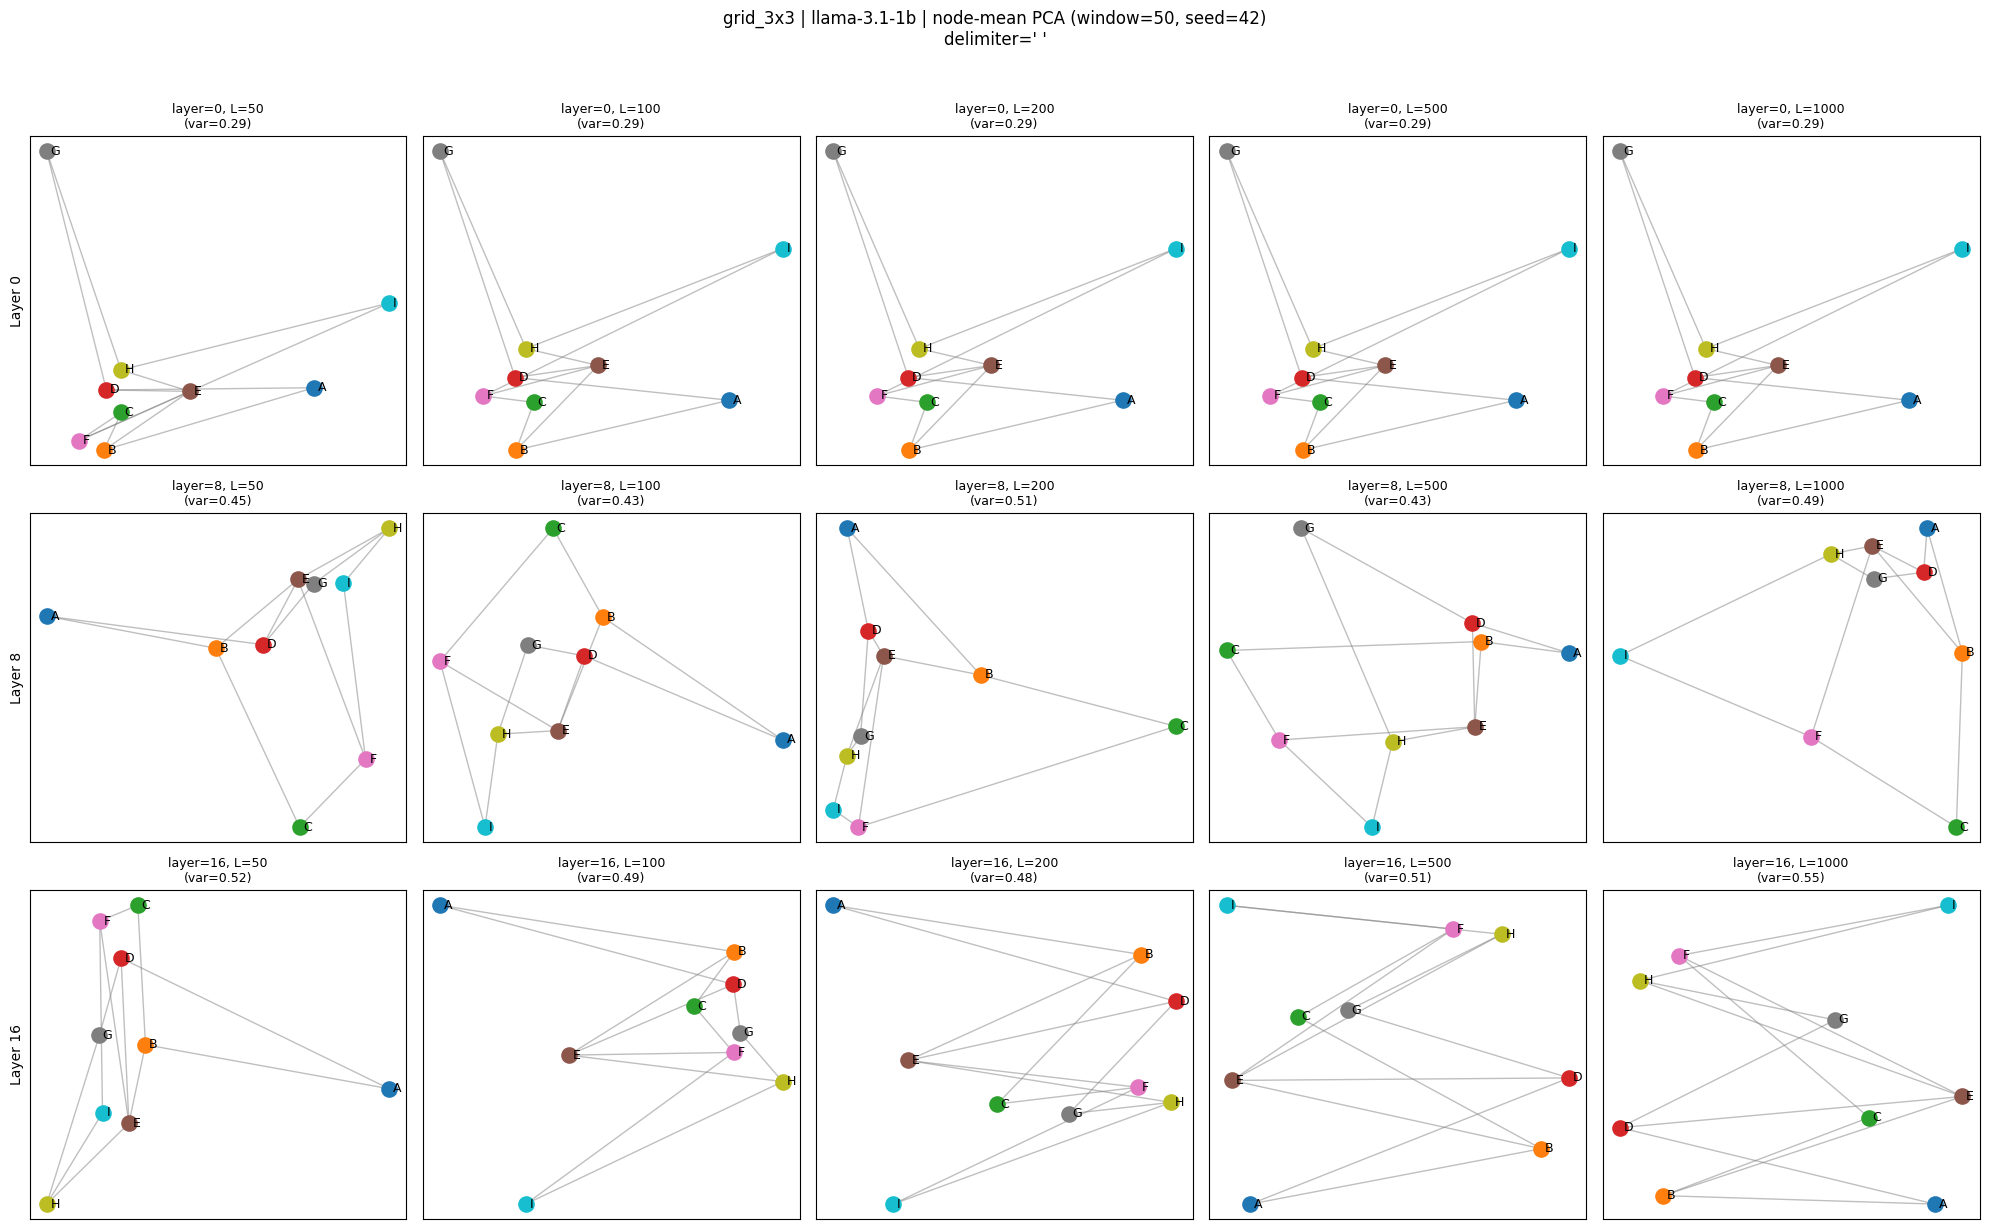

Saved to pca_grid_grid_3x3_llama-3.1-1b.png


In [24]:
model_name = 'llama-3.2-1b'
model_id = MODEL_IDS[model_name]
model = HookedTransformer.from_pretrained(
    model_id,
    dtype=dtype,
    device=DEVICE,
    fold_ln=False,
    center_writing_weights=False,
    center_unembed=False,
)
model.eval()
LAYERS_TO_PLOT = [0, 8, 16, 24, 31]  # embedding + evenly-spaced + last
SEQ_LENGTHS = [50, 100, 200, 500, 1000]
run_analysis(model, layers_to_plot=LAYERS_TO_PLOT, seq_lengths=SEQ_LENGTHS)


In [25]:
del model

In [ ]:
model_id = 'meta-llama/Llama-3.2-3B'
model = HookedTransformer.from_pretrained(
    model_id,
    dtype=dtype,
    device=DEVICE,
    fold_ln=False,
    center_writing_weights=False,
    center_unembed=False,
)
model.eval()


Walk length: 1000 tokens, first 30: ['A', 'B', 'E', 'D', 'G', 'H', 'E', 'H', 'E', 'B', 'E', 'F', 'I', 'H', 'I', 'H', 'G', 'D', 'E', 'D', 'G', 'D', 'A', 'B', 'C', 'F', 'E', 'F', 'E', 'D']
Done. Shape: (9, 3072) (n_nodes × hidden_dim)
  T=50: 9/9 nodes seen in window
  T=100: 9/9 nodes seen in window
  T=200: 9/9 nodes seen in window
  T=500: 9/9 nodes seen in window
  T=1000: 9/9 nodes seen in window
Available layers: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28}
Valid layers: [0, 4, 8, 12, 16, 20, 24, 27]
Saved to /Users/dani/code/geometric-interpretability-LLMs/images/pca_grid_grid_3x3_meta-llama/Llama-3.1-8B-2026-02-19_14-41-17.png


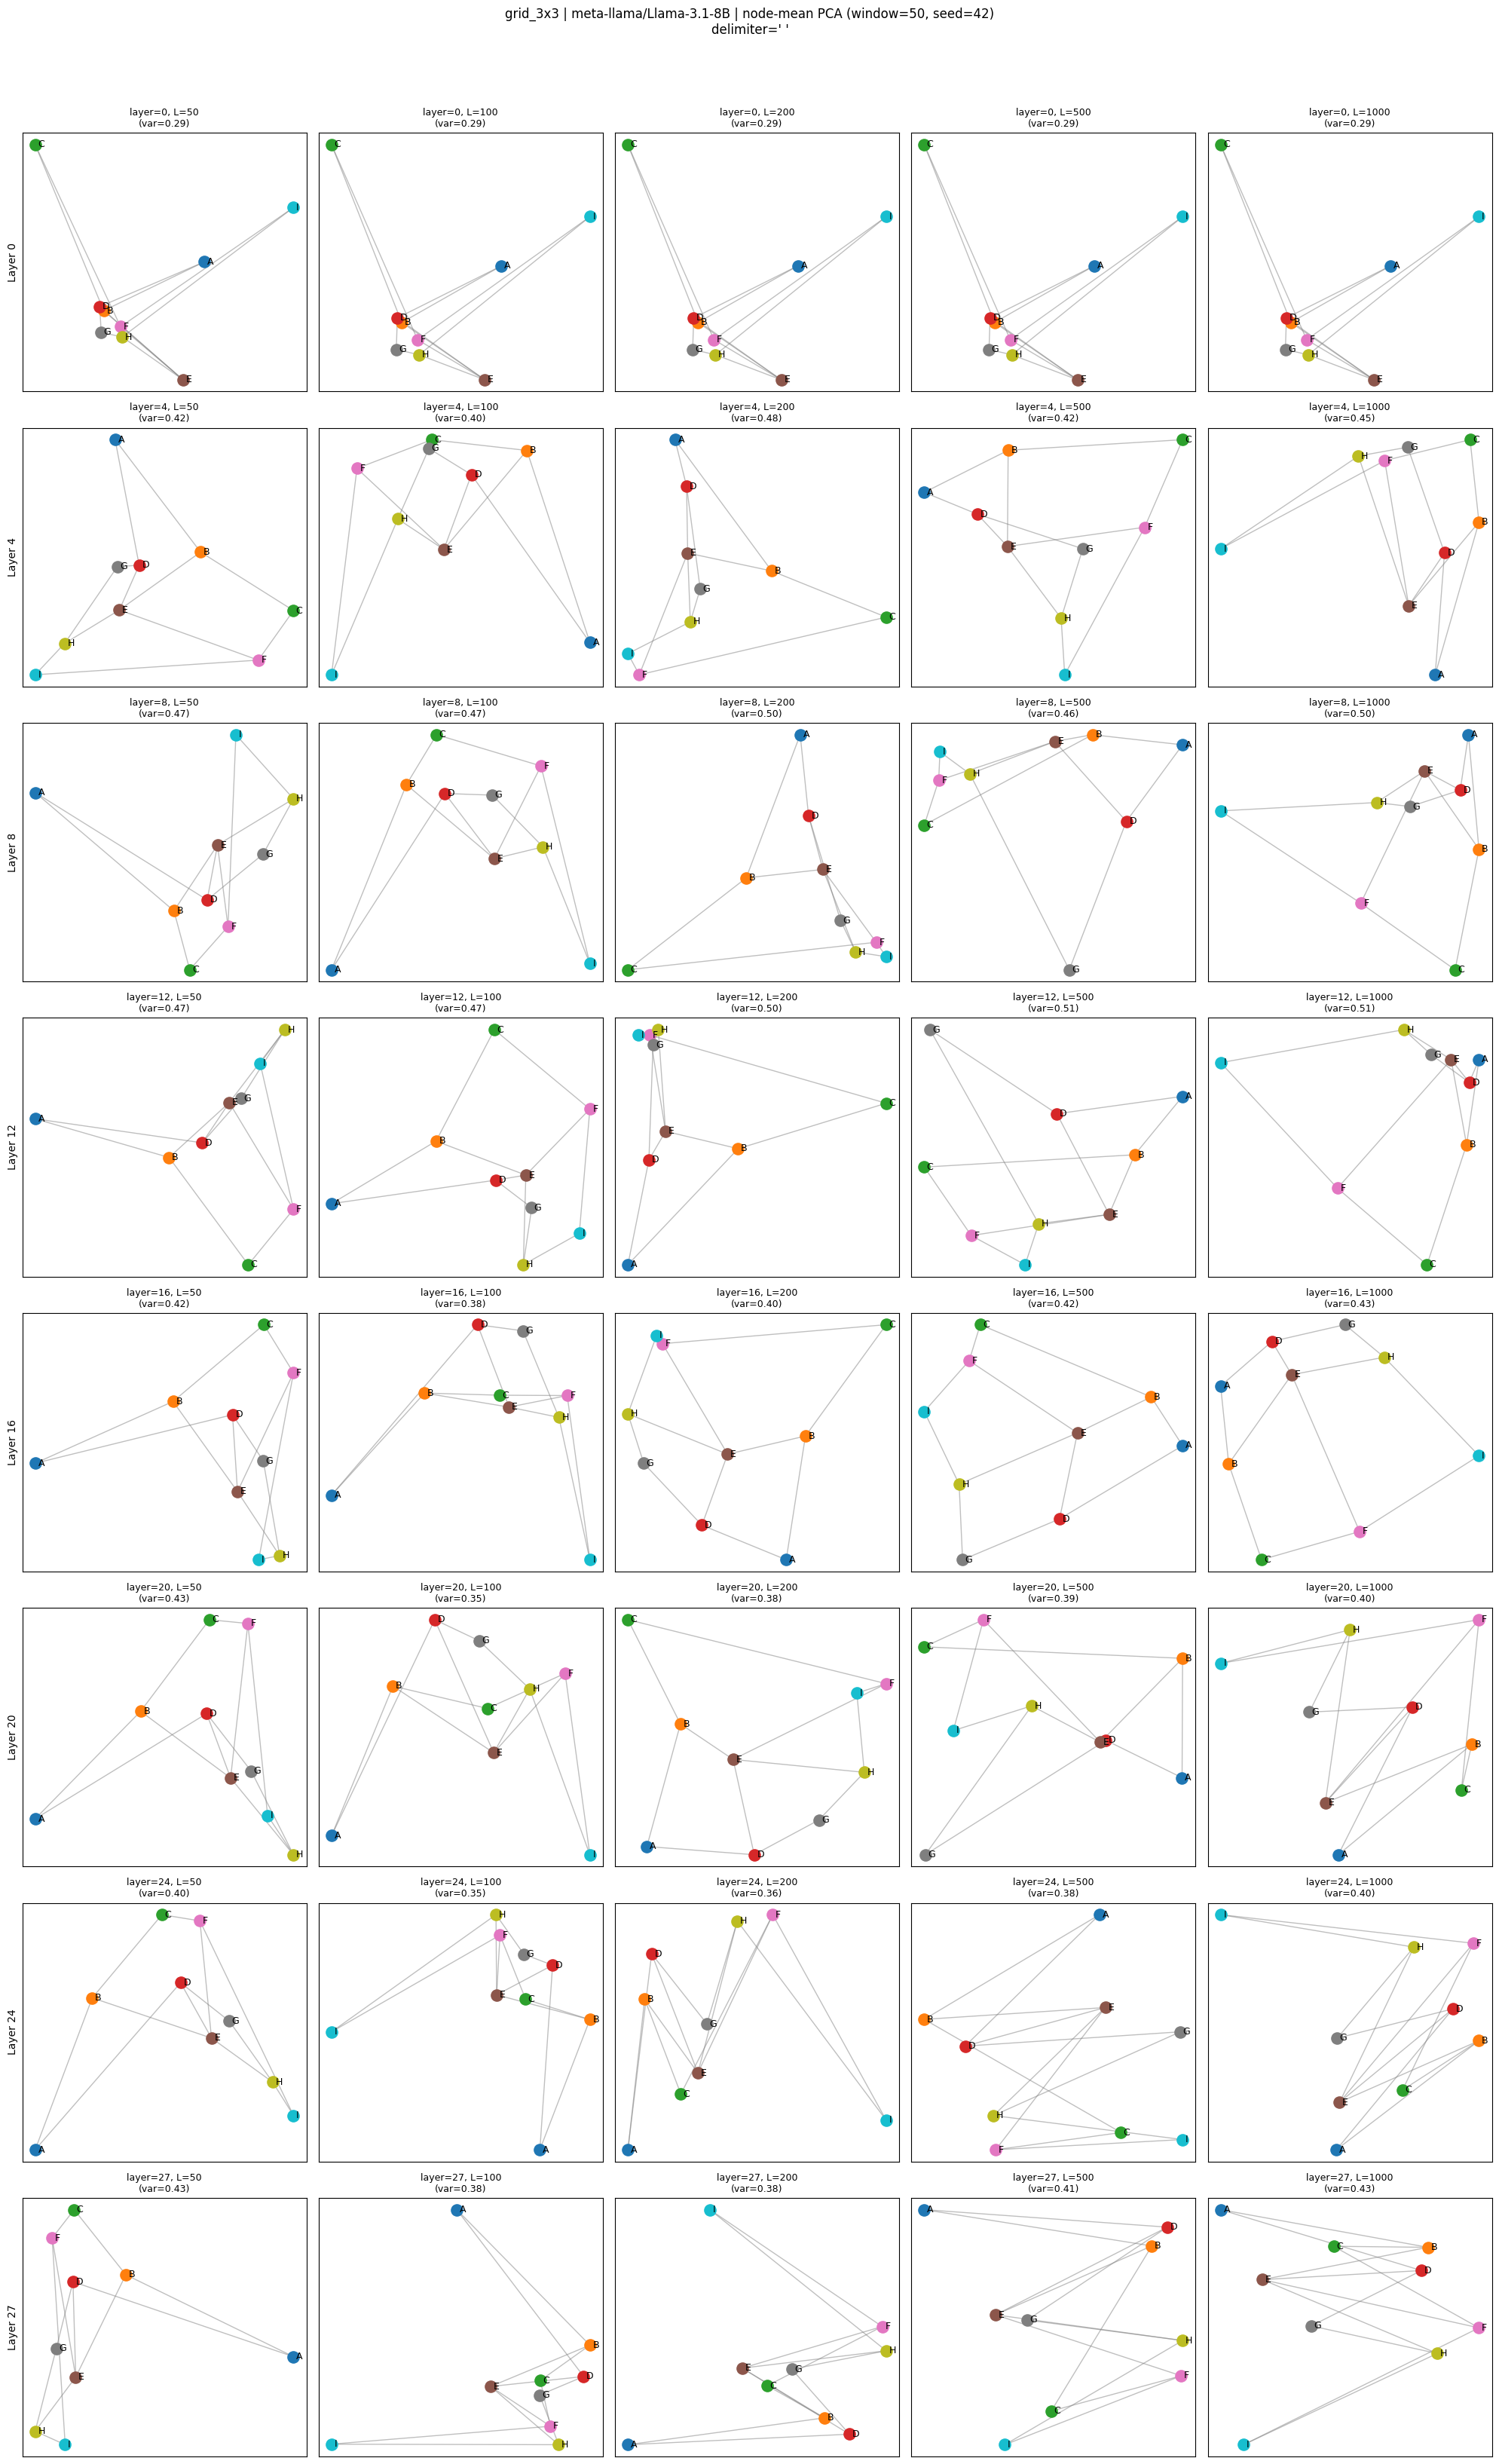

In [ ]:
layers = list[int](range(model.cfg.n_layers))
# plot every 4th layer and the last layer
layers_to_plot = layers[::4] + [layers[-1]]
seq_lengths = [50, 100, 200, 500, 1000]

run_analysis(model, layers_to_plot=layers_to_plot, seq_lengths=seq_lengths, model_name=model_id)


In [10]:
# del model
model_id = 'meta-llama/Llama-3.1-8B'
model = HookedTransformer.from_pretrained(
    model_id,
    dtype=torch.bfloat16,
    device=DEVICE,
    fold_ln=False,
    center_writing_weights=False,
    center_unembed=False,
)
model.eval()


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Loaded pretrained model meta-llama/Llama-3.1-8B into HookedTransformer


HookedTransformer(
  (embed): Embed()
  (hook_embed): HookPoint()
  (blocks): ModuleList(
    (0-31): 32 x TransformerBlock(
      (ln1): RMSNorm(
        (hook_scale): HookPoint()
        (hook_normalized): HookPoint()
      )
      (ln2): RMSNorm(
        (hook_scale): HookPoint()
        (hook_normalized): HookPoint()
      )
      (attn): GroupedQueryAttention(
        (hook_k): HookPoint()
        (hook_q): HookPoint()
        (hook_v): HookPoint()
        (hook_z): HookPoint()
        (hook_attn_scores): HookPoint()
        (hook_pattern): HookPoint()
        (hook_result): HookPoint()
        (hook_rot_k): HookPoint()
        (hook_rot_q): HookPoint()
      )
      (mlp): GatedMLP(
        (hook_pre): HookPoint()
        (hook_pre_linear): HookPoint()
        (hook_post): HookPoint()
      )
      (hook_attn_in): HookPoint()
      (hook_q_input): HookPoint()
      (hook_k_input): HookPoint()
      (hook_v_input): HookPoint()
      (hook_mlp_in): HookPoint()
      (hook_attn_out)

Walk length: 1000 tokens, first 30: ['A', 'B', 'E', 'D', 'G', 'H', 'E', 'H', 'E', 'B', 'E', 'F', 'I', 'H', 'I', 'H', 'G', 'D', 'E', 'D', 'G', 'D', 'A', 'B', 'C', 'F', 'E', 'F', 'E', 'D']
Done. Shape: (9, 4096) (n_nodes × hidden_dim)
  T=50: 9/9 nodes seen in window
  T=100: 9/9 nodes seen in window
  T=200: 9/9 nodes seen in window
  T=500: 9/9 nodes seen in window
  T=1000: 9/9 nodes seen in window
Available layers: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32}
Valid layers: [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30, 31]
Saved to dani/images/pca_grid_grid_3x3_meta-llama_Llama-3.1-8B-2026-02-19_15-51-42.png


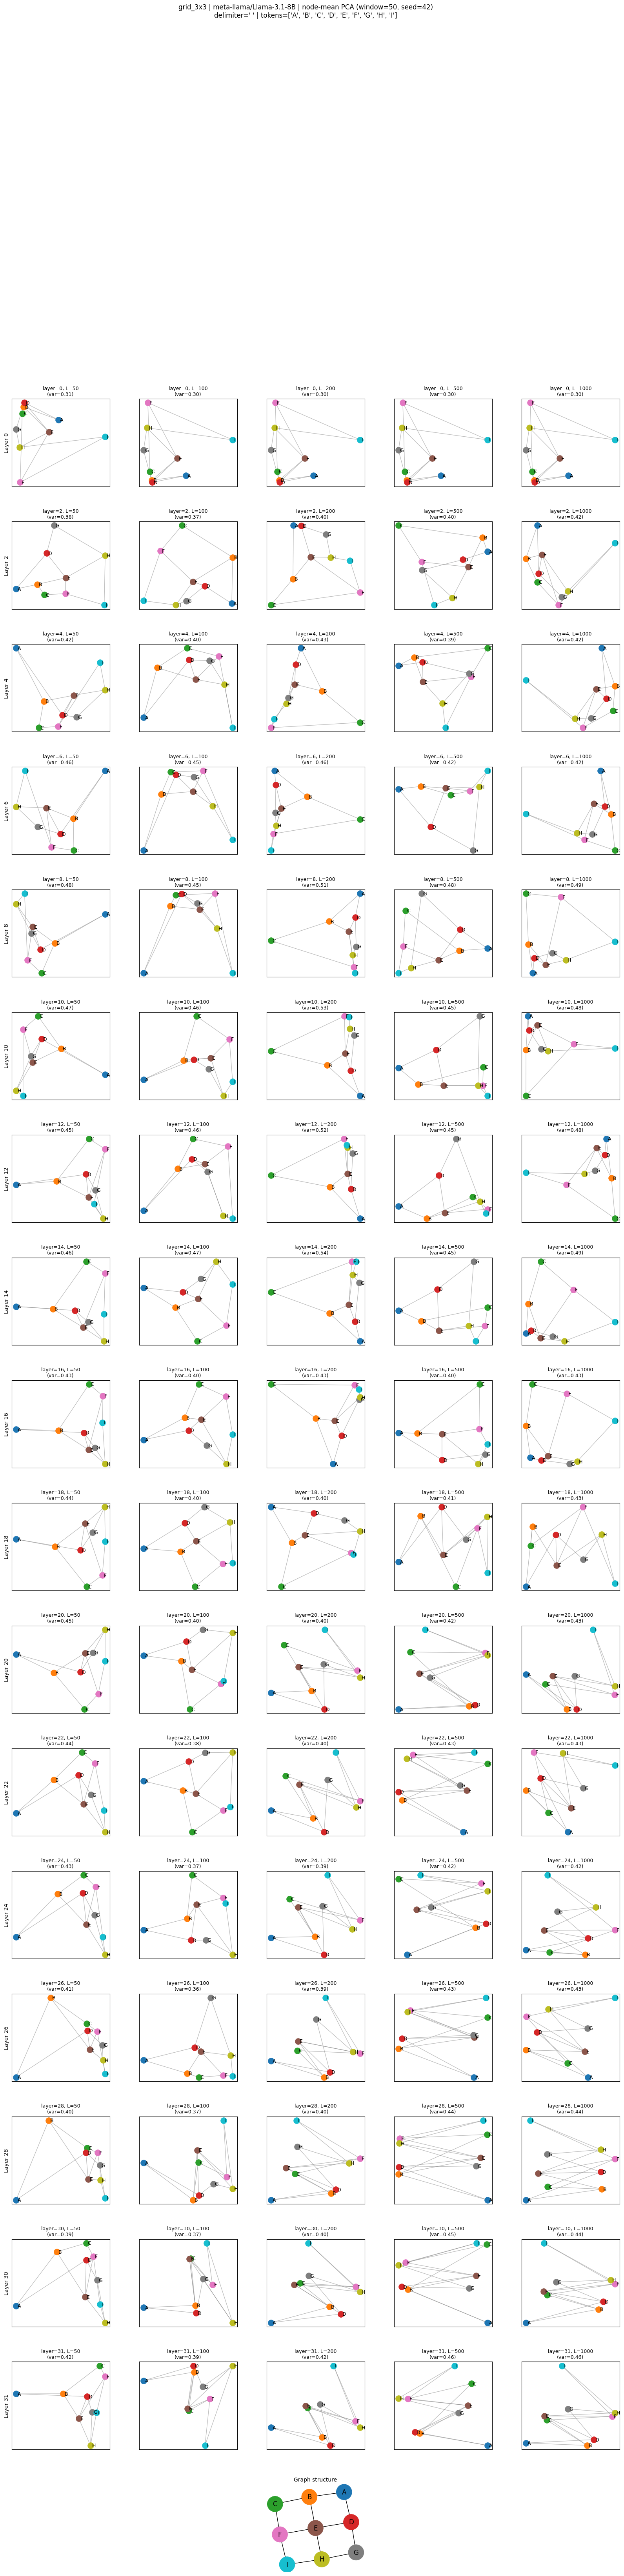

In [35]:
layers = list[int](range(model.cfg.n_layers))
# plot every 4th layer and the last layer
layers_to_plot = layers[::2] + [layers[-1]]
seq_lengths = [50, 100, 200, 500, 1000]
point_tokens = ["A", "B", "C", "D", "E", "F", "G", "H", "I"]

run_analysis(model, layers_to_plot=layers_to_plot, seq_lengths=seq_lengths, model_name=model_id, point_tokens=point_tokens)


Walk length: 1000 tokens, first 30: ['car', 'apple', 'house', 'dog', 'sky', 'book', 'house', 'book', 'house', 'apple', 'house', 'tree', 'word', 'book', 'word', 'book', 'sky', 'dog', 'house', 'dog', 'sky', 'dog', 'car', 'apple', 'blue', 'tree', 'house', 'tree', 'house', 'dog']
Done. Shape: (9, 4096) (n_nodes × hidden_dim)
  T=10: 6/9 nodes seen in window
  T=50: 9/9 nodes seen in window
  T=100: 9/9 nodes seen in window
  T=200: 9/9 nodes seen in window
  T=500: 9/9 nodes seen in window
  T=1000: 9/9 nodes seen in window
Available layers: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32}
Valid layers: [0, 4, 8, 12, 16, 20, 24, 28, 31]
Saved to dani/images/pca_grid_grid_3x3_meta-llama_Llama-3.1-8B-2026-02-19_15-27-23.png


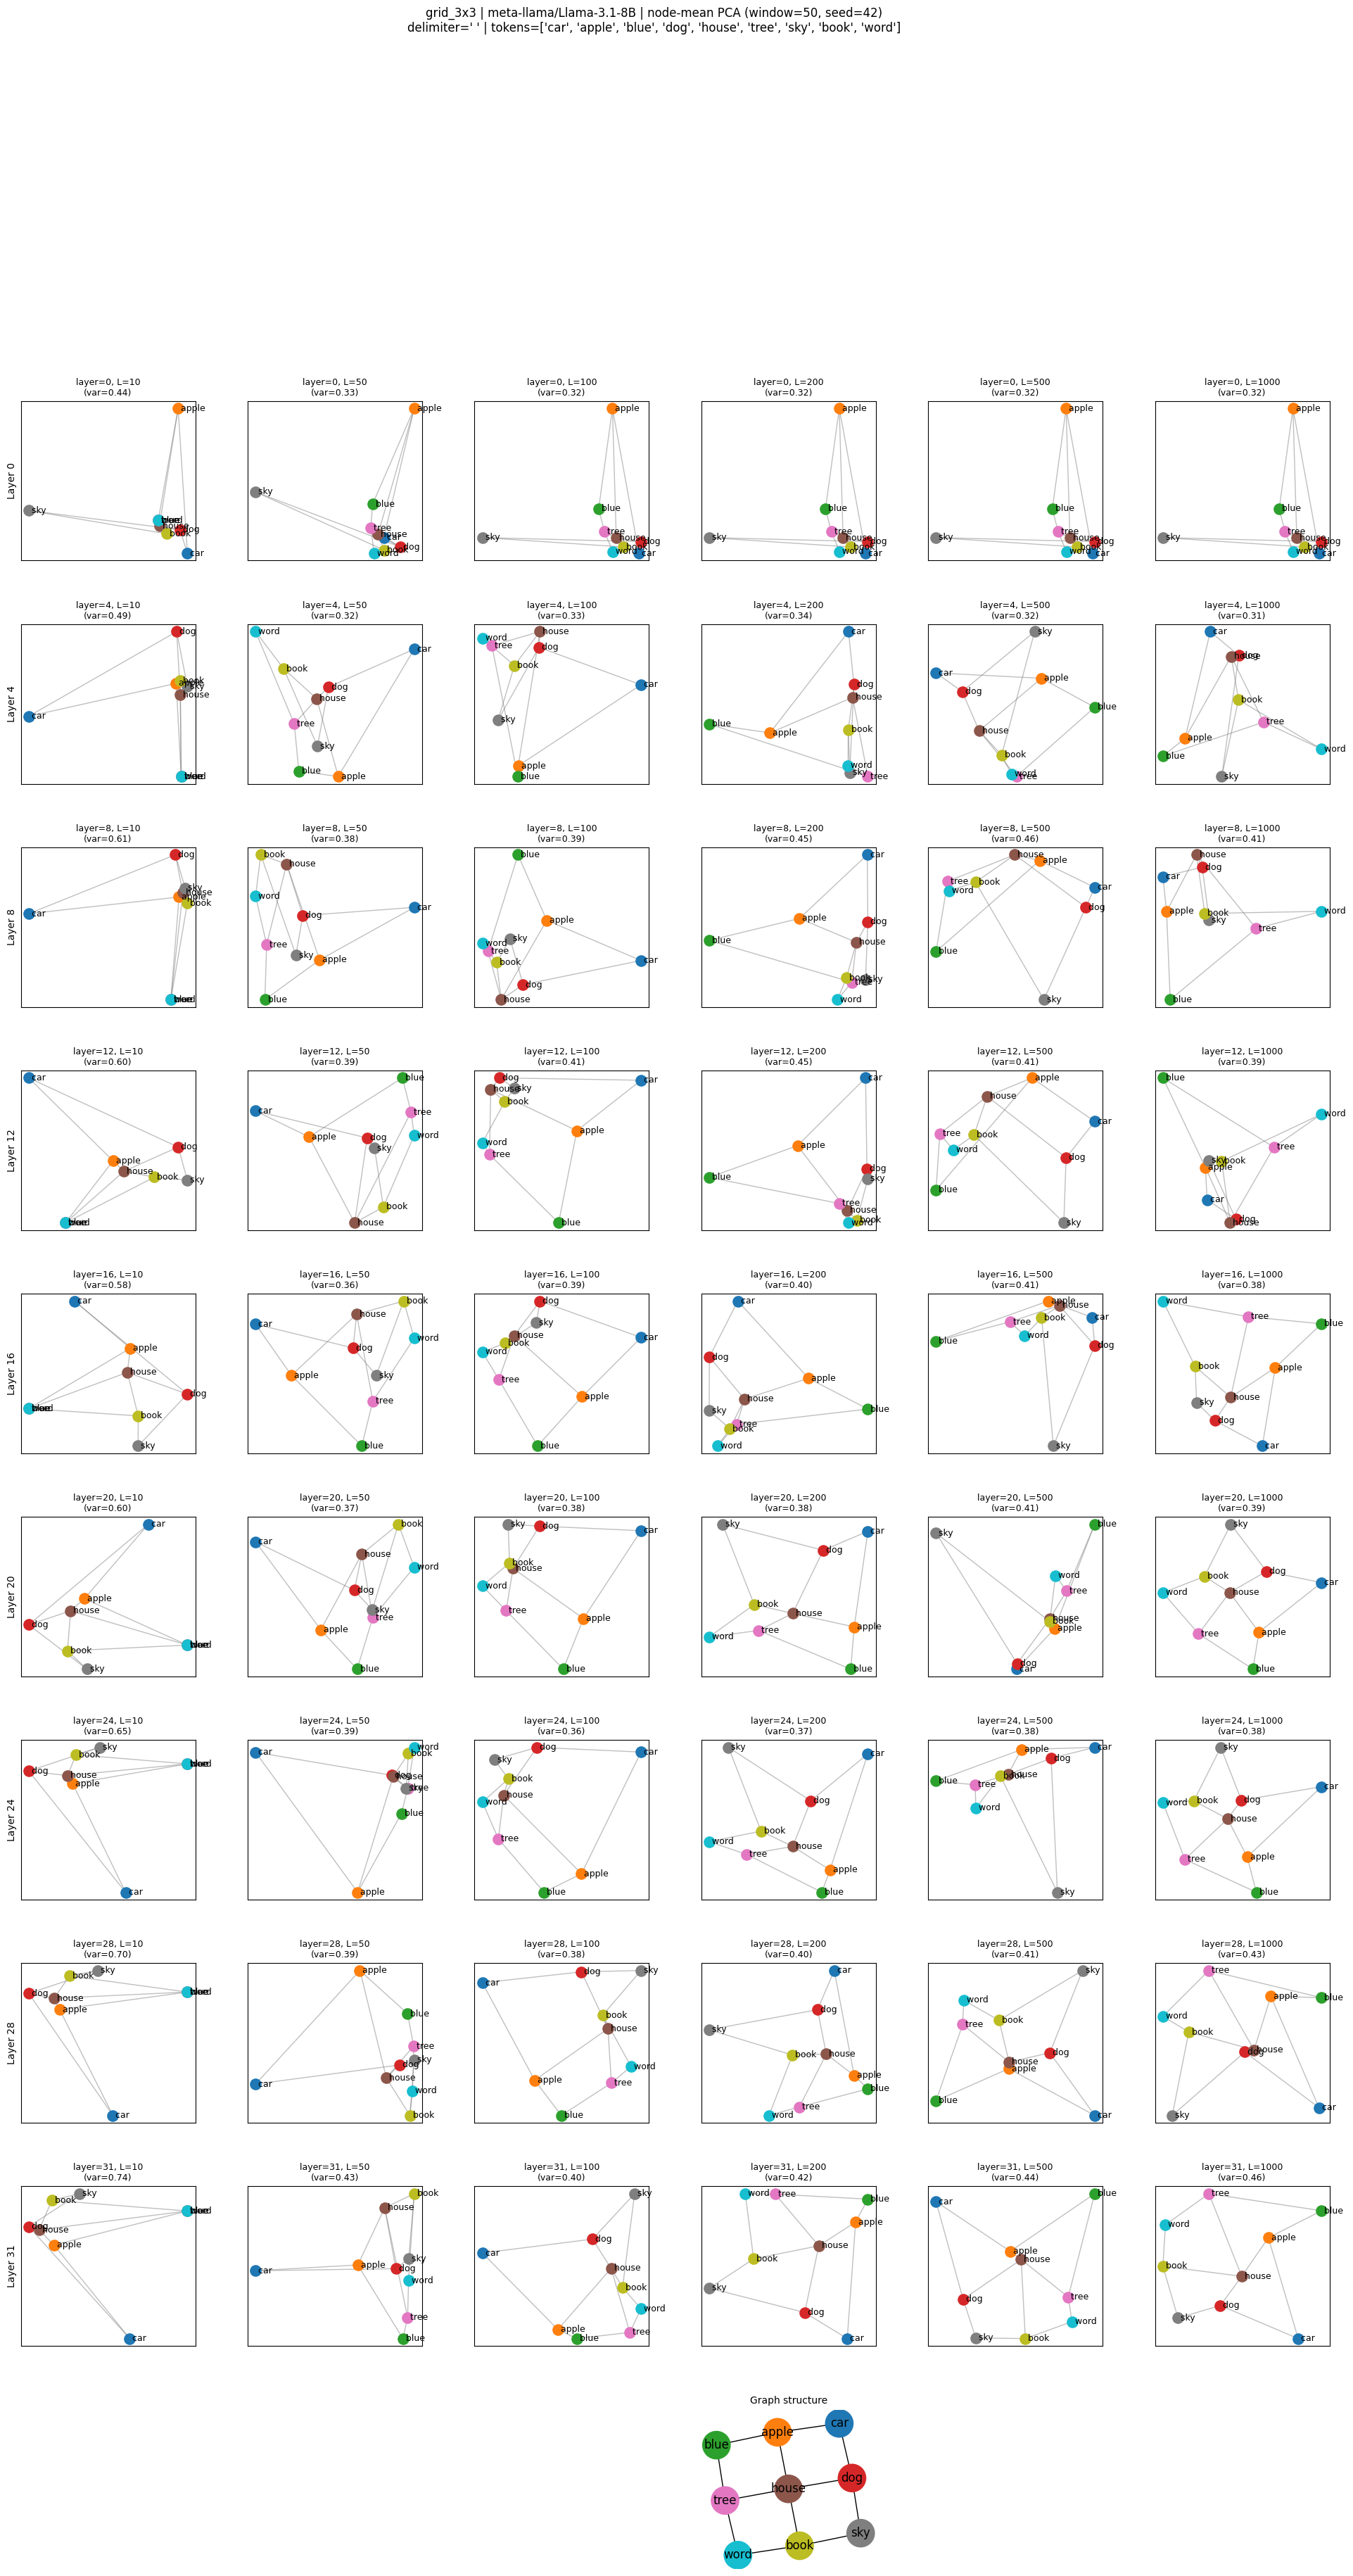

In [30]:
layers = list[int](range(model.cfg.n_layers))
# plot every 4th layer and the last layer
layers_to_plot = layers[::4] + [layers[-1]]
seq_lengths = [10, 50, 100, 200, 500, 1000]
point_tokens = [
    "car",
    "apple",
    "blue",
    "dog",
    "house",
    "tree",
    "sky",
    "book",
    "word"
]

run_analysis(model, layers_to_plot=layers_to_plot, seq_lengths=seq_lengths, model_name=model_id, point_tokens=point_tokens)


Walk length: 1000 tokens, first 30: ['A', 'B', 'E', 'D', 'G', 'H', 'E', 'H', 'E', 'B', 'E', 'F', 'I', 'H', 'I', 'H', 'G', 'D', 'E', 'D', 'G', 'D', 'A', 'B', 'C', 'F', 'E', 'F', 'E', 'D']
Done. Shape: (9, 4096) (n_nodes × hidden_dim)
  T=10: 6/9 nodes seen in window
  T=50: 9/9 nodes seen in window
  T=100: 9/9 nodes seen in window
  T=200: 9/9 nodes seen in window
  T=500: 9/9 nodes seen in window
  T=1000: 9/9 nodes seen in window
Available layers: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32}
Valid layers: [0, 4, 8, 12, 16, 20, 24, 28, 31]
Saved to dani/images/pca_grid_grid_3x3_meta-llama_Llama-3.1-8B-2026-02-19_15-28-35.png


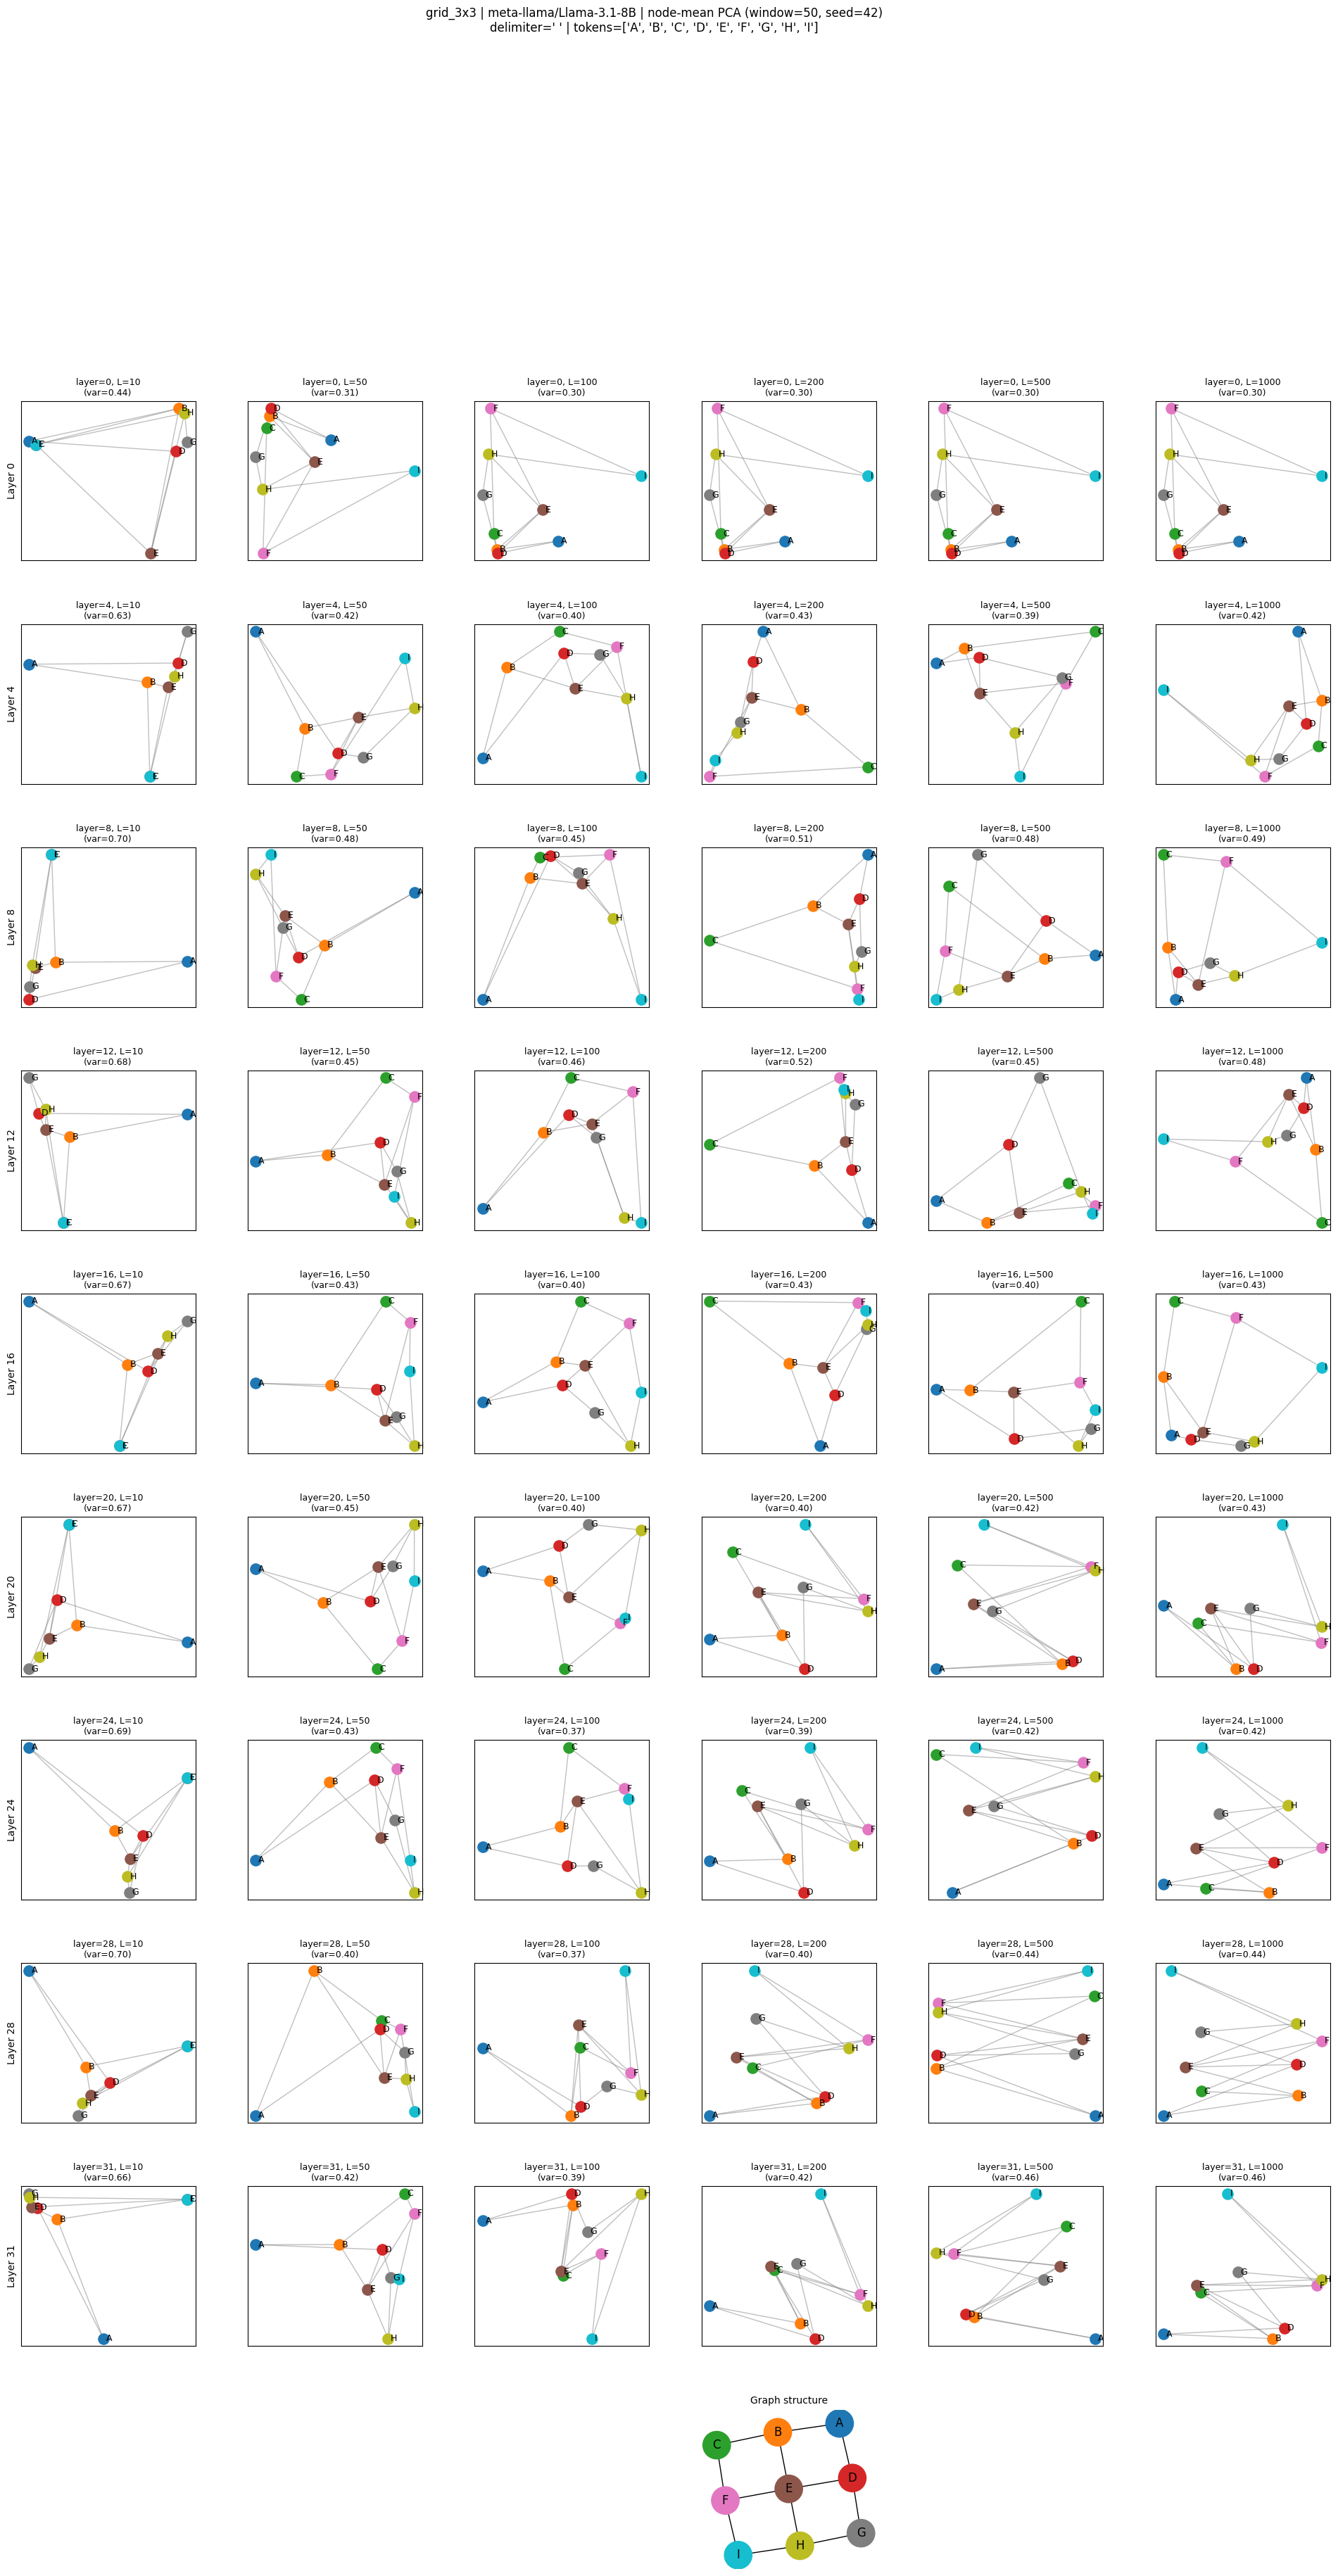

In [31]:
layers = list[int](range(model.cfg.n_layers))
# plot every 4th layer and the last layer
layers_to_plot = layers[::4] + [layers[-1]]
seq_lengths = [10, 50, 100, 200, 500, 1000]
point_tokens = [
    "A",
    "B",
    "C",
    "D",
    "E",
    "F",
    "G",
    "H",
    "I"
]

run_analysis(model, layers_to_plot=layers_to_plot, seq_lengths=seq_lengths, model_name=model_id, point_tokens=point_tokens)


Walk length: 1000 tokens, first 30: ['1', '2', '5', '4', '7', '8', '5', '8', '5', '2', '5', '6', '9', '8', '9', '8', '7', '4', '5', '4', '7', '4', '1', '2', '3', '6', '5', '6', '5', '4']
Done. Shape: (9, 4096) (n_nodes × hidden_dim)
  T=10: 6/9 nodes seen in window
  T=50: 9/9 nodes seen in window
  T=100: 9/9 nodes seen in window
  T=200: 9/9 nodes seen in window
  T=500: 9/9 nodes seen in window
  T=1000: 9/9 nodes seen in window
Available layers: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32}
Valid layers: [0, 4, 8, 12, 16, 20, 24, 28, 31]
Saved to dani/images/pca_grid_grid_3x3_meta-llama_Llama-3.1-8B-2026-02-19_15-46-08.png


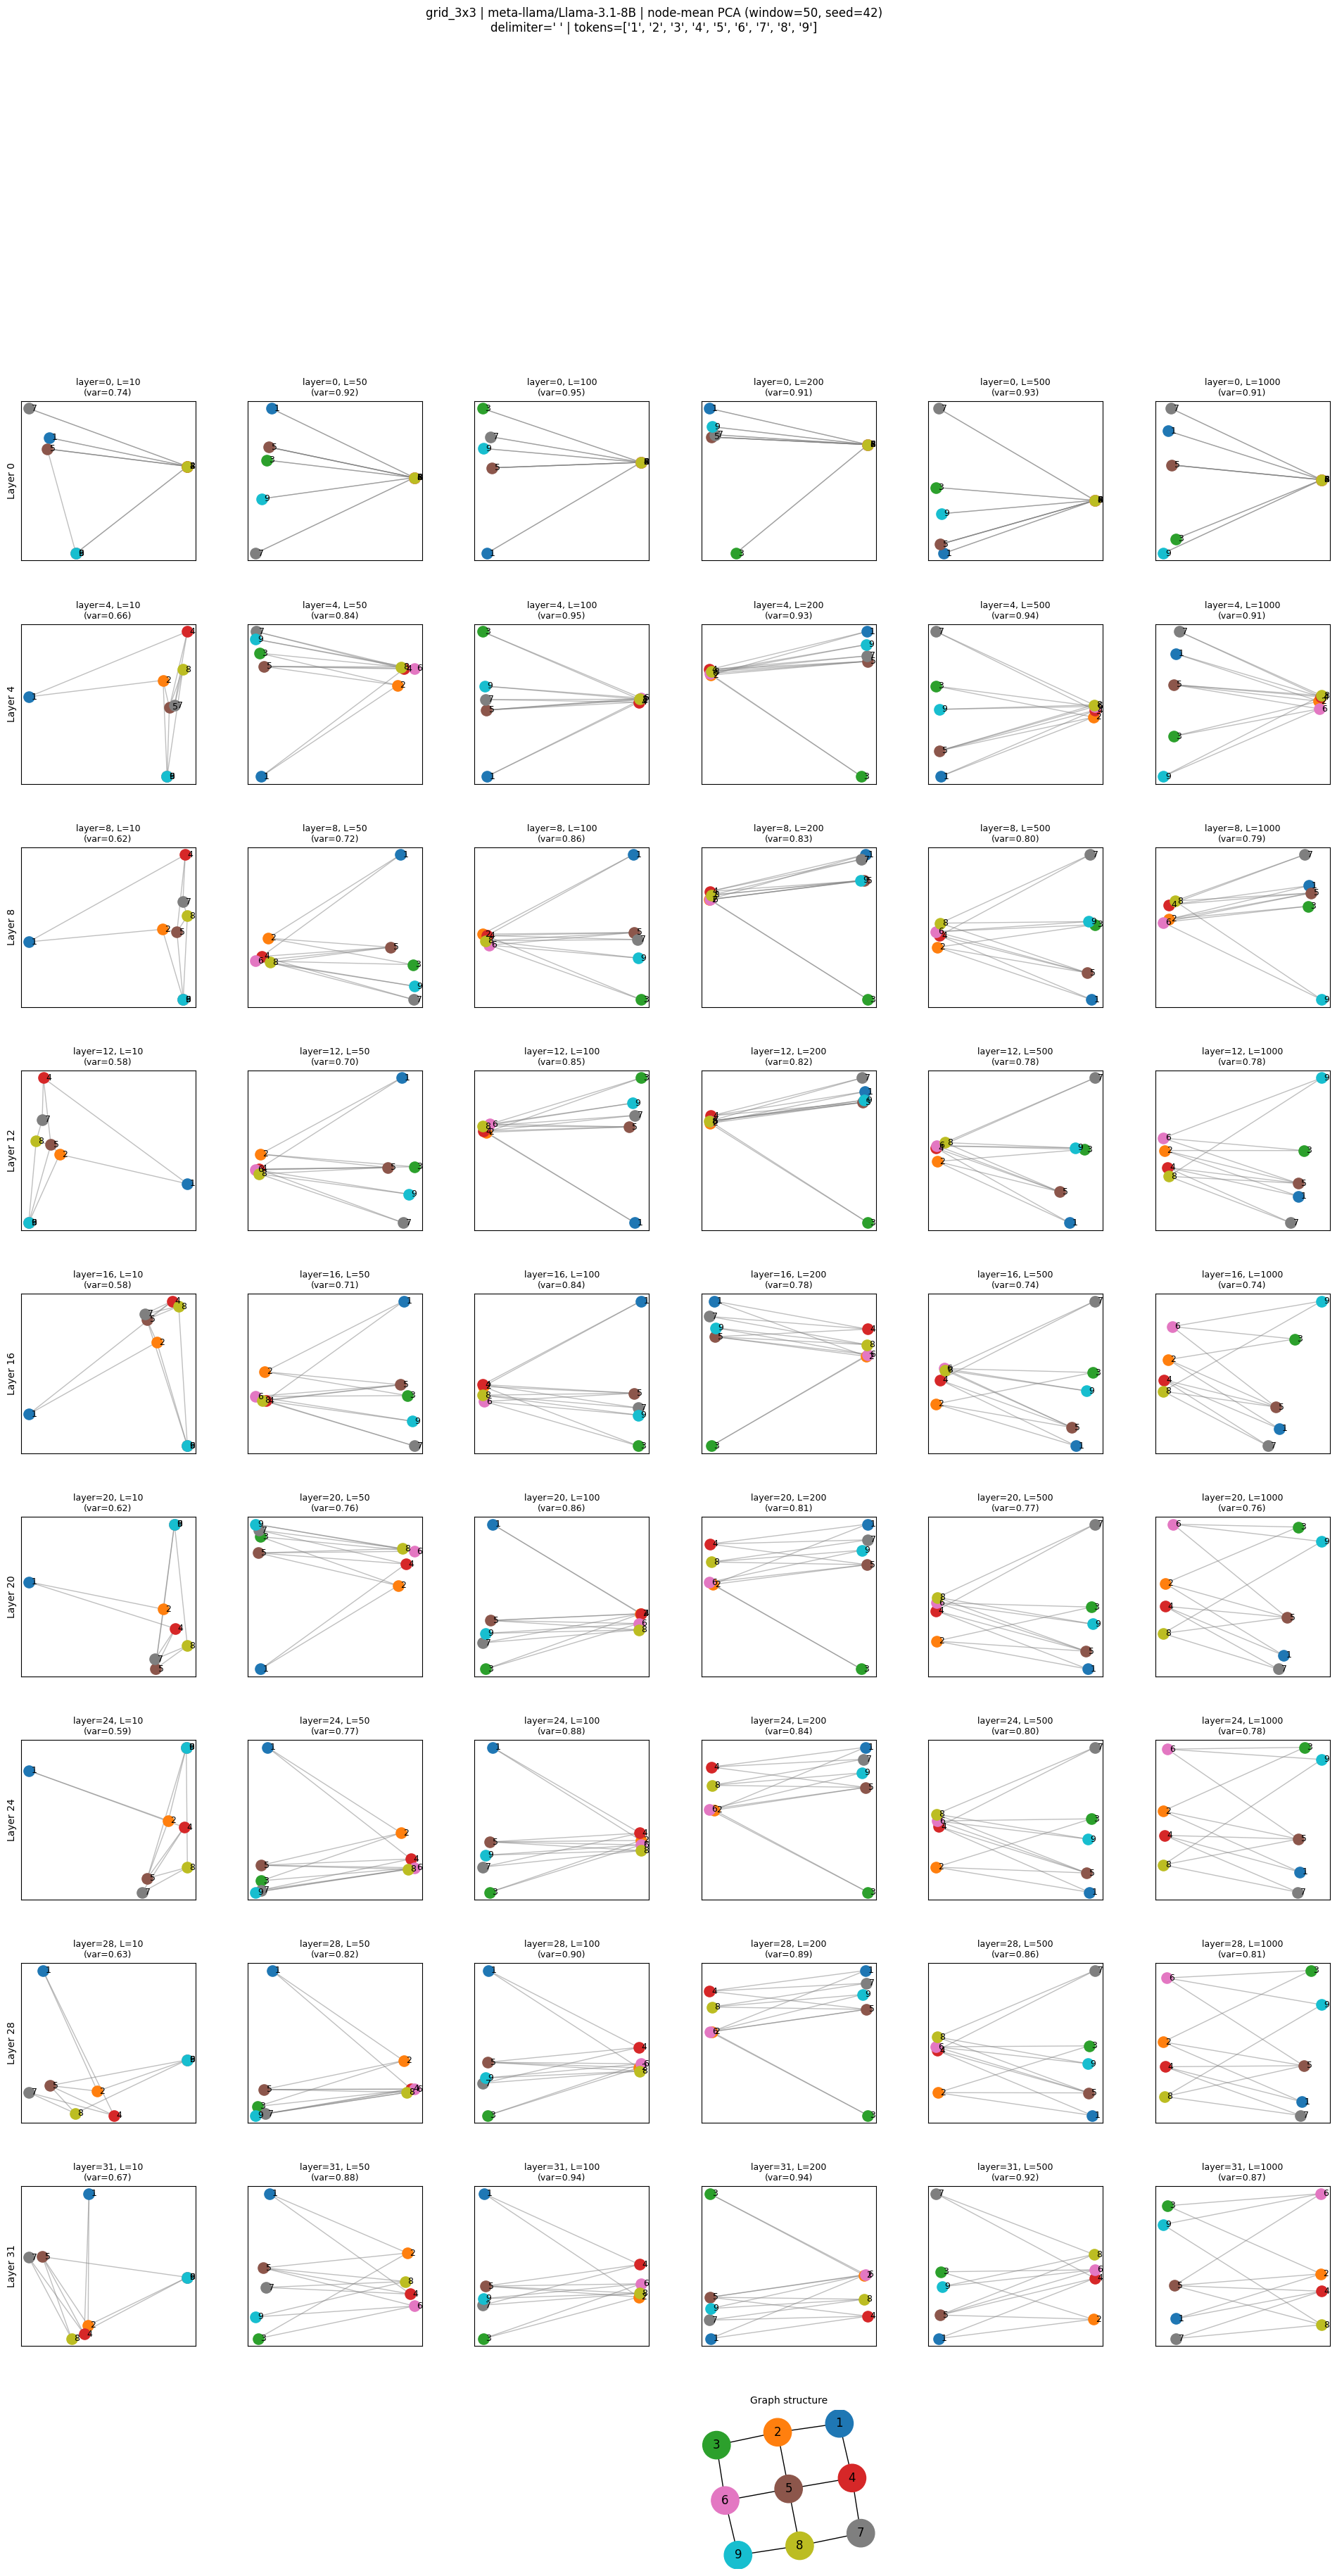

In [34]:
layers = list[int](range(model.cfg.n_layers))
# plot every 4th layer and the last layer
layers_to_plot = layers[::4] + [layers[-1]]
seq_lengths = [10, 50, 100, 200, 500, 1000]
point_tokens = [
   "1",
   "2",
   "3",
   "4",
   "5",
   "6",
   "7",
   "8",
   "9",
]

run_analysis(model, layers_to_plot=layers_to_plot, seq_lengths=seq_lengths, model_name=model_id, point_tokens=point_tokens)
